In [2]:
# ============================================================
# CELL 1 — Import & Load Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
file_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/data/processed/churn_cleaned.csv'
df = pd.read_csv(file_path)

print("✅ Data loaded!")
print(f"📊 Shape: {df.shape}")

✅ Data loaded!
📊 Shape: (7043, 20)


In [3]:
# ============================================================
# CELL 2 — Why Customers Churn
# ============================================================

churned = df[df['Churn'] == 'Yes']
loyal   = df[df['Churn'] == 'No']

print("=" * 60)
print("WHY CUSTOMERS CHURN — KEY FINDINGS")
print("=" * 60)

print(f"""
1️⃣  TENURE
    • Churned customers stay only {churned['tenure'].mean():.1f} months on average
    • Loyal customers stay {loyal['tenure'].mean():.1f} months on average
    • NEW customers are {loyal['tenure'].mean()/churned['tenure'].mean():.1f}x more likely to churn

2️⃣  MONTHLY CHARGES
    • Churned customers pay ${churned['MonthlyCharges'].mean():.2f}/month
    • Loyal customers pay  ${loyal['MonthlyCharges'].mean():.2f}/month
    • High bills = higher churn risk

3️⃣  CONTRACT TYPE
    • Month-to-month churn rate : {df[df['Contract']=='Month-to-month']['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%
    • One year churn rate       : {df[df['Contract']=='One year']['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%
    • Two year churn rate       : {df[df['Contract']=='Two year']['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%

4️⃣  INTERNET SERVICE
    • Fiber optic churn rate : {df[df['InternetService']=='Fiber optic']['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%
    • DSL churn rate         : {df[df['InternetService']=='DSL']['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%
    • No internet churn rate : {df[df['InternetService']=='No']['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%
""")

WHY CUSTOMERS CHURN — KEY FINDINGS

1️⃣  TENURE
    • Churned customers stay only 18.0 months on average
    • Loyal customers stay 37.6 months on average
    • NEW customers are 2.1x more likely to churn

2️⃣  MONTHLY CHARGES
    • Churned customers pay $74.44/month
    • Loyal customers pay  $61.27/month
    • High bills = higher churn risk

3️⃣  CONTRACT TYPE
    • Month-to-month churn rate : 42.7%
    • One year churn rate       : 11.3%
    • Two year churn rate       : 2.8%

4️⃣  INTERNET SERVICE
    • Fiber optic churn rate : 41.9%
    • DSL churn rate         : 19.0%
    • No internet churn rate : 7.4%



In [4]:
# ============================================================
# CELL 3 — Revenue Impact Analysis
# ============================================================

monthly_revenue_lost = churned['MonthlyCharges'].sum()
annual_revenue_lost  = monthly_revenue_lost * 12
avg_revenue_per_customer = df['MonthlyCharges'].mean()

print("=" * 60)
print("💸 REVENUE IMPACT ANALYSIS")
print("=" * 60)

print(f"""
📉 REVENUE LOST TO CHURN
    • Churned customers         : {len(churned):,}
    • Monthly revenue lost      : ${monthly_revenue_lost:,.2f}
    • Annual revenue lost       : ${annual_revenue_lost:,.2f}

💡 RETENTION OPPORTUNITY
    • If we retain just 10% of churners:
      → Customers saved         : {int(len(churned)*0.10):,}
      → Monthly revenue saved   : ${monthly_revenue_lost*0.10:,.2f}
      → Annual revenue saved    : ${annual_revenue_lost*0.10:,.2f}

    • If we retain just 20% of churners:
      → Customers saved         : {int(len(churned)*0.20):,}
      → Monthly revenue saved   : ${monthly_revenue_lost*0.20:,.2f}
      → Annual revenue saved    : ${annual_revenue_lost*0.20:,.2f}
""")

💸 REVENUE IMPACT ANALYSIS

📉 REVENUE LOST TO CHURN
    • Churned customers         : 1,869
    • Monthly revenue lost      : $139,130.85
    • Annual revenue lost       : $1,669,570.20

💡 RETENTION OPPORTUNITY
    • If we retain just 10% of churners:
      → Customers saved         : 186
      → Monthly revenue saved   : $13,913.09
      → Annual revenue saved    : $166,957.02

    • If we retain just 20% of churners:
      → Customers saved         : 373
      → Monthly revenue saved   : $27,826.17
      → Annual revenue saved    : $333,914.04



In [5]:
# ============================================================
# CELL 4 — High Risk Customer Segments
# ============================================================

print("=" * 60)
print("⚠️  HIGH RISK CUSTOMER SEGMENTS")
print("=" * 60)

# Segment 1 — Month to month + Fiber optic
seg1 = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic')
]
seg1_churn = seg1['Churn'].value_counts(normalize=True)['Yes'] * 100

# Segment 2 — Senior citizens
seg2 = df[df['SeniorCitizen'] == 'Yes']
seg2_churn = seg2['Churn'].value_counts(normalize=True)['Yes'] * 100

# Segment 3 — No online security
seg3 = df[df['OnlineSecurity'] == 'No']
seg3_churn = seg3['Churn'].value_counts(normalize=True)['Yes'] * 100

# Segment 4 — Electronic check
seg4 = df[df['PaymentMethod'] == 'Electronic check']
seg4_churn = seg4['Churn'].value_counts(normalize=True)['Yes'] * 100

print(f"""
🔴 SEGMENT 1 — Month-to-month + Fiber optic
    • Total customers : {len(seg1):,}
    • Churn rate      : {seg1_churn:.1f}%

🔴 SEGMENT 2 — Senior Citizens
    • Total customers : {len(seg2):,}
    • Churn rate      : {seg2_churn:.1f}%

🔴 SEGMENT 3 — No Online Security
    • Total customers : {len(seg3):,}
    • Churn rate      : {seg3_churn:.1f}%

🔴 SEGMENT 4 — Electronic Check Payment
    • Total customers : {len(seg4):,}
    • Churn rate      : {seg4_churn:.1f}%
""")

⚠️  HIGH RISK CUSTOMER SEGMENTS

🔴 SEGMENT 1 — Month-to-month + Fiber optic
    • Total customers : 2,128
    • Churn rate      : 54.6%

🔴 SEGMENT 2 — Senior Citizens
    • Total customers : 1,142
    • Churn rate      : 41.7%

🔴 SEGMENT 3 — No Online Security
    • Total customers : 3,498
    • Churn rate      : 41.8%

🔴 SEGMENT 4 — Electronic Check Payment
    • Total customers : 2,365
    • Churn rate      : 45.3%



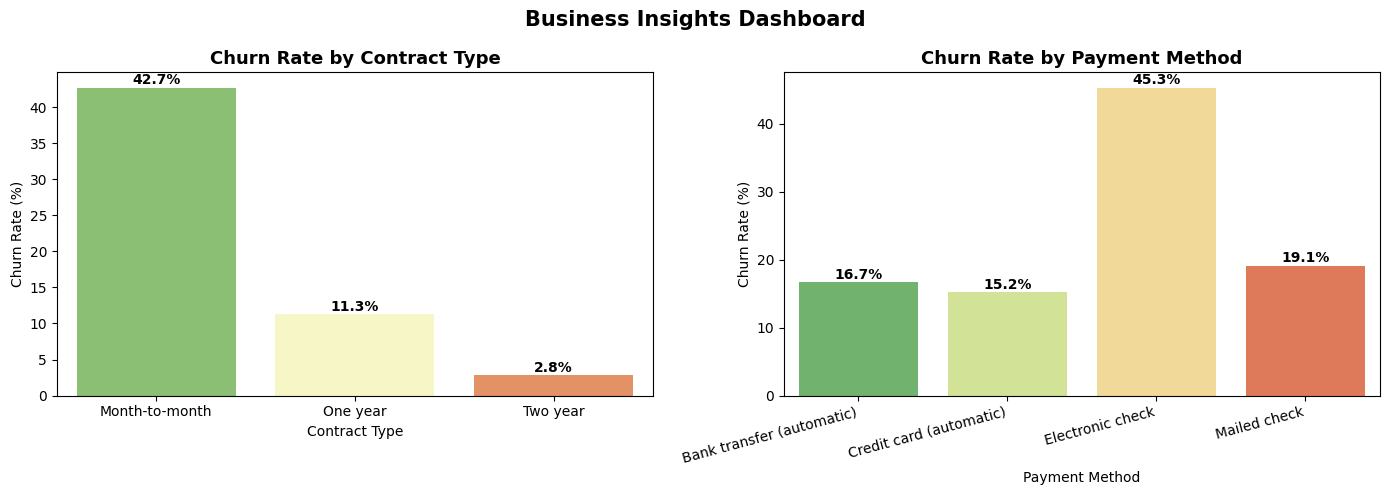

✅ Chart saved!


In [6]:
# ============================================================
# CELL 5 — Business Recommendations Chart
# ============================================================

# Churn rate by contract
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']

# Churn rate by payment method
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
payment_churn.columns = ['PaymentMethod', 'Churn Rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1
sns.barplot(
    data=contract_churn,
    x='Contract', y='Churn Rate',
    palette='RdYlGn_r', ax=axes[0]
)
axes[0].set_title('Churn Rate by Contract Type',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn['Churn Rate']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%',
                  ha='center', fontweight='bold')

# Chart 2
sns.barplot(
    data=payment_churn,
    x='PaymentMethod', y='Churn Rate',
    palette='RdYlGn_r', ax=axes[1]
)
axes[1].set_title('Churn Rate by Payment Method',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=15, ha='right'
)
for i, v in enumerate(payment_churn['Churn Rate']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%',
                  ha='center', fontweight='bold')

plt.suptitle('Business Insights Dashboard',
              fontsize=15, fontweight='bold')
plt.tight_layout()

save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/12_business_insights.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [7]:
# ============================================================
# CELL 6 — Final Business Recommendations
# ============================================================

print("=" * 60)
print("✅ BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1️⃣  OFFER LONG TERM CONTRACTS
    → Month-to-month customers churn at 43%
    → Give discounts to switch to 1 or 2 year plans
    → Target: reduce month-to-month churn by 15%

2️⃣  FIX FIBER OPTIC EXPERIENCE
    → Fiber optic churn is highest at 42%
    → Investigate service quality & pricing
    → Bundle online security for free

3️⃣  CHANGE PAYMENT METHOD
    → Electronic check users churn at 45%
    → Offer incentives to switch to auto-pay
    → Example: $5 discount for auto-pay signup

4️⃣  TARGET NEW CUSTOMERS
    → Most churn happens in first 12 months
    → Create onboarding program for new customers
    → Assign dedicated support for first 3 months

5️⃣  SENIOR CITIZEN RETENTION
    → Senior citizens churn more
    → Create special senior plans with lower prices
    → Offer dedicated phone support

✅ BUSINESS INSIGHTS PHASE COMPLETE!
🎯 Next Phase: Streamlit Web App
""")

✅ BUSINESS RECOMMENDATIONS

1️⃣  OFFER LONG TERM CONTRACTS
    → Month-to-month customers churn at 43%
    → Give discounts to switch to 1 or 2 year plans
    → Target: reduce month-to-month churn by 15%

2️⃣  FIX FIBER OPTIC EXPERIENCE
    → Fiber optic churn is highest at 42%
    → Investigate service quality & pricing
    → Bundle online security for free

3️⃣  CHANGE PAYMENT METHOD
    → Electronic check users churn at 45%
    → Offer incentives to switch to auto-pay
    → Example: $5 discount for auto-pay signup

4️⃣  TARGET NEW CUSTOMERS
    → Most churn happens in first 12 months
    → Create onboarding program for new customers
    → Assign dedicated support for first 3 months

5️⃣  SENIOR CITIZEN RETENTION
    → Senior citizens churn more
    → Create special senior plans with lower prices
    → Offer dedicated phone support

✅ BUSINESS INSIGHTS PHASE COMPLETE!
🎯 Next Phase: Streamlit Web App

